# Portfolio Project: SpaceX Falcon 9 First-Stage Landing Prediction
## 07 — Interactive Visual Analytics with Plotly Dash

**Portfolio Project | Business Analytics & Data Analytics**

This notebook presents an interactive analytics workflow. It uses the dashboard input, `spacex_launch_dash.csv`, and the core **interaction Dashboard design**: launch-site selection, payload-range filtering, a success pie chart, and a payload/outcome scatter plot.

### Research role of this stage
The dashboard translates earlier exploratory analysis into an **interactive decision-support interface**. Rather than presenting only fixed charts, it allows a user to change the launch site and payload range and immediately inspect how the historical landing outcomes change.

### Workflow
1. Load and validate the local dashboard CSV.
2. Audit the dashboard dataset and its relationship to Notebook 06.
3. Compute site, payload-band, and booster success summaries for interpretation.
4. Build reusable Plotly figure functions.
5. Validate those functions outside the Dash server.
6. Define the interactive Dash layout and callbacks.
7. Export a standalone portfolio Dash application script.
8. Document the audited findings and limitations.

> **Data-scope note.** `spacex_launch_dash.csv` contains **56 historical launch records**, matching the 56-record snapshot used by Notebook 06. It is not the same sample as the 90-launch modeling dataset used in Notebooks 03 and 05. Dashboard findings therefore apply to this specific 56-record snapshot.

## 1. Environment and dashboard input

The notebook uses the same input as Notebook 06. 

In [12]:
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

try:
    from dash import Dash, dcc, html, Input, Output
    DASH_AVAILABLE = True
except ImportError:
    DASH_AVAILABLE = False

pd.set_option("display.max_columns", None)

INPUT_PATH = Path("spacex_launch_dash.csv")
APP_OUTPUT_PATH = Path("spacex_dash_app_portfolio.py")

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"{INPUT_PATH} was not found. Place spacex_launch_dash.csv beside this notebook."
    )

spacex_df = pd.read_csv(INPUT_PATH)

if "Unnamed: 0" in spacex_df.columns:
    spacex_df = spacex_df.drop(columns="Unnamed: 0")

print(f"Loaded {len(spacex_df):,} rows × {spacex_df.shape[1]} analytical columns from {INPUT_PATH}")
print(f"Dash available in this environment: {DASH_AVAILABLE}")
spacex_df.head()

Loaded 56 rows × 6 analytical columns from spacex_launch_dash.csv
Dash available in this environment: True


,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


## 2. Validate the dashboard dataset

The dash app requires launch site, binary landing class, payload mass, and booster category. The checks below verify those fields and establish the exact sample used by the dashboard.

In [13]:
required_columns = [
    "Flight Number",
    "Launch Site",
    "class",
    "Payload Mass (kg)",
    "Booster Version",
    "Booster Version Category",
]

missing_columns = sorted(set(required_columns) - set(spacex_df.columns))
if missing_columns:
    raise ValueError(f"Missing required dashboard columns: {missing_columns}")

min_payload = float(spacex_df["Payload Mass (kg)"].min())
max_payload = float(spacex_df["Payload Mass (kg)"].max())

validation = pd.Series({
    "rows": len(spacex_df),
    "columns": spacex_df.shape[1],
    "launch_sites": spacex_df["Launch Site"].nunique(),
    "booster_categories": spacex_df["Booster Version Category"].nunique(),
    "minimum_payload_kg": min_payload,
    "maximum_payload_kg": max_payload,
    "missing_values": int(spacex_df.isna().sum().sum()),
    "duplicate_rows": int(spacex_df.duplicated().sum()),
    "class_values": sorted(spacex_df["class"].unique().tolist()),
    "successful_landings": int(spacex_df["class"].sum()),
    "overall_success_rate": round(spacex_df["class"].mean(), 4),
}, name="value")

validation.to_frame()

,value
rows,56
columns,6
launch_sites,4
booster_categories,5
minimum_payload_kg,0.0
maximum_payload_kg,9600.0
missing_values,0
duplicate_rows,0
class_values,"[0, 1]"
successful_landings,24


The dashboard sample contains **56 missions**, including **24 successful landing records**, for an overall observed success rate of **42.9%**. Payload mass ranges from **0 to 9,600 kg**.

## 3. Site-level performance

**Which site has the largest number of successful launches and which has the highest success rate?** \
Both counts and rates are calculated explicitly.

In [14]:
site_summary = (
    spacex_df.groupby("Launch Site")
    .agg(
        Launches=("class", "size"),
        Successful_Landings=("class", "sum"),
        Success_Rate=("class", "mean"),
    )
    .sort_values(["Successful_Landings", "Success_Rate"], ascending=False)
)

site_summary["Success_Rate_Pct"] = (100 * site_summary["Success_Rate"]).round(1)
site_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
Launch Site,,,,
KSC LC-39A,13,10,0.769231,76.9
CCAFS LC-40,26,7,0.269231,26.9
VAFB SLC-4E,10,4,0.400000,40.0
CCAFS SLC-40,7,3,0.428571,42.9


### Interpretation

**KSC LC-39A leads on both measures in this 56-record dataset:** it records the largest number of successful landings (**10**) and the highest observed site success rate (**76.9%, 10/13**).

The remaining observed rates are CCAFS SLC-40 **42.9% (3/7)**, VAFB SLC-4E **40.0% (4/10)**, and CCAFS LC-40 **26.9% (7/26)**. These values match the site summary in Notebook 06 because the two notebooks use the same 56-record historical snapshot.

## 4. Payload-range performance

We divide the 0–10,000 kg slider domain into 2,000 kg bands. These bins support interpretation but do **not** replace the continuous slider in the dashboard.

In [15]:
payload_bins = [0, 2000, 4000, 6000, 8000, 10000]
payload_labels = [
    "0–2,000",
    "2,000–4,000",
    "4,000–6,000",
    "6,000–8,000",
    "8,000–10,000",
]

payload_audit = spacex_df.copy()
payload_audit["Payload_Band"] = pd.cut(
    payload_audit["Payload Mass (kg)"],
    bins=payload_bins,
    labels=payload_labels,
    include_lowest=True,
    right=False,
)

payload_summary = (
    payload_audit.groupby("Payload_Band", observed=False)
    .agg(
        Launches=("class", "size"),
        Successful_Landings=("class", "sum"),
        Success_Rate=("class", "mean"),
    )
)

payload_summary["Success_Rate_Pct"] = (100 * payload_summary["Success_Rate"]).round(1)
payload_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
Payload_Band,,,,
"0–2,000",13,3,0.230769,23.1
"2,000–4,000",21,13,0.619048,61.9
"4,000–6,000",13,5,0.384615,38.5
"6,000–8,000",4,0,0.000000,0.0
"8,000–10,000",5,3,0.600000,60.0


### Interpretation

Using these fixed 2,000 kg audit bands, the **2,000–4,000 kg** range has the highest observed success rate at **61.9% (13/21)**, narrowly followed by **8,000–10,000 kg at 60.0% (3/5)**. The **6,000–8,000 kg** band records **0 successful landings in 4 missions**.

The relationship is therefore clearly **non-linear** in this 56-record snapshot. The small sample sizes—especially at heavier payloads—mean these band comparisons should be treated as descriptive rather than as stable population estimates.

## 5. Booster-category performance

The scatter plot colors missions by booster-version category. Computing category-level rates makes the visual interpretation explicit.

In [16]:
booster_summary = (
    spacex_df.groupby("Booster Version Category")
    .agg(
        Launches=("class", "size"),
        Successful_Landings=("class", "sum"),
        Success_Rate=("class", "mean"),
    )
    .sort_values(["Success_Rate", "Launches"], ascending=False)
)

booster_summary["Success_Rate_Pct"] = (100 * booster_summary["Success_Rate"]).round(1)
booster_summary

,Launches,Successful_Landings,Success_Rate,Success_Rate_Pct
Booster Version Category,,,,
B5,1,1,1.000000,100.0
FT,24,16,0.666667,66.7
B4,11,6,0.545455,54.5
v1.1,15,1,0.066667,6.7
v1.0,5,0,0.000000,0.0


### Interpretation

`B5` has a nominal **100% success rate**, but it appears only once in this dataset, so it is not a robust basis for comparison. Among categories with multiple observations, `FT` has the strongest observed performance at **66.7% (16/24)**, followed by `B4` at **54.5% (6/11)**. `v1.1` records **6.7% (1/15)** and `v1.0` **0% (0/5)**.

This pattern is consistent with substantial improvement across later booster generations, but booster category is also associated with mission era and other operational changes; the dashboard does not establish a causal booster effect.

## 6. Reusable figure functions

The portfolio separates **data/figure logic** from **Dash callback wiring**. This makes the analytical behavior easier to test and audit.

In [17]:
SITE_OPTIONS = ["ALL"] + sorted(spacex_df["Launch Site"].unique().tolist())

def make_success_pie(selected_site):
    """Return the dashboard pie chart for all sites or one selected site."""
    if selected_site not in SITE_OPTIONS:
        raise ValueError(f"Unknown launch site: {selected_site}")

    if selected_site == "ALL":
        success_by_site = (
            spacex_df.loc[spacex_df["class"].eq(1)]
            .groupby("Launch Site")
            .size()
            .rename("Successful Landings")
            .reset_index()
        )

        return px.pie(
            success_by_site,
            values="Successful Landings",
            names="Launch Site",
            title="Successful Falcon 9 Landings by Launch Site",
            hole=0.25,
        )

    site_df = spacex_df.loc[spacex_df["Launch Site"].eq(selected_site)].copy()
    outcome_counts = (
        site_df["class"]
        .map({0: "Failure / no success", 1: "Success"})
        .value_counts()
        .rename_axis("Outcome")
        .reset_index(name="Missions")
    )

    return px.pie(
        outcome_counts,
        values="Missions",
        names="Outcome",
        title=f"Landing Outcomes — {selected_site}",
        hole=0.25,
    )


def make_payload_scatter(selected_site, payload_range):
    """Return payload-versus-outcome scatter plot for the selected filters."""
    if selected_site not in SITE_OPTIONS:
        raise ValueError(f"Unknown launch site: {selected_site}")

    low, high = map(float, payload_range)
    if low > high:
        raise ValueError("Payload-range lower bound cannot exceed upper bound.")

    filtered = spacex_df.loc[
        spacex_df["Payload Mass (kg)"].between(low, high, inclusive="both")
    ].copy()

    if selected_site != "ALL":
        filtered = filtered.loc[filtered["Launch Site"].eq(selected_site)]

    scope = "All Sites" if selected_site == "ALL" else selected_site

    if filtered.empty:
        fig = go.Figure()
        fig.add_annotation(
            text="No missions match the selected site and payload range.",
            x=0.5, y=0.5, xref="paper", yref="paper",
            showarrow=False, font={"size": 15},
        )
        fig.update_layout(
            title=f"Payload Mass vs. Landing Outcome — {scope}",
            xaxis_title="Payload Mass (kg)",
            yaxis_title="Landing outcome",
        )
        return fig

    filtered["Landing Outcome"] = filtered["class"].map(
        {0: "Failure / no success", 1: "Success"}
    )

    fig = px.scatter(
        filtered,
        x="Payload Mass (kg)",
        y="class",
        color="Booster Version Category",
        symbol="Landing Outcome",
        hover_data=[
            "Flight Number",
            "Launch Site",
            "Booster Version",
            "Landing Outcome",
        ],
        title=f"Payload Mass vs. Landing Outcome — {scope}",
    )

    fig.update_yaxes(
        tickmode="array",
        tickvals=[0, 1],
        ticktext=["Failure / no success", "Success"],
        range=[-0.15, 1.15],
        title="Landing outcome",
    )
    fig.update_xaxes(title="Payload Mass (kg)")
    return fig

## 7. Validate the figure logic before launching Dash

The figures are generated directly in the notebook so that their data can be audited without starting a web server. The assertions verify the most important callback semantics.

Figure-function audit passed:
- All-sites pie represents 24 successful landing records.
- KSC pie represents all 13 KSC missions.
- Full-range scatter represents all 56 missions.


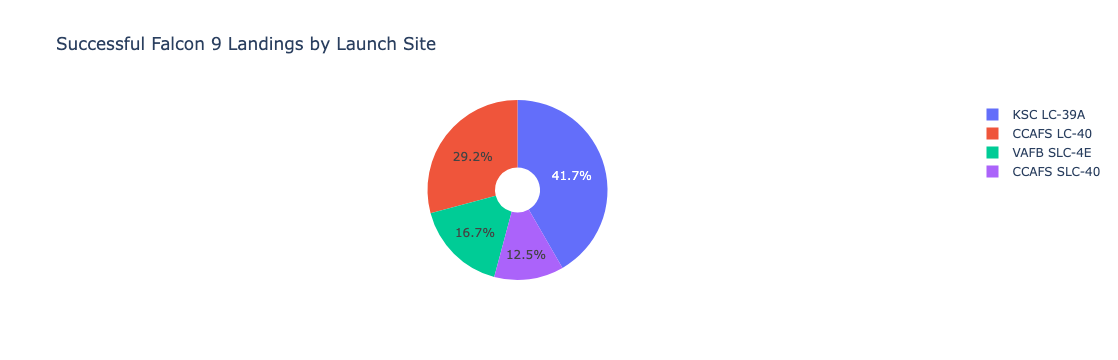

In [18]:
all_sites_pie = make_success_pie("ALL")
ksc_pie = make_success_pie("KSC LC-39A")
all_sites_scatter = make_payload_scatter("ALL", [min_payload, max_payload])

# Audit the all-sites pie: it must contain exactly the 24 successful records.
assert sum(all_sites_pie.data[0]["values"]) == int(spacex_df["class"].sum()) == 24

# Audit the KSC pie: it must contain all 13 KSC missions.
assert sum(ksc_pie.data[0]["values"]) == int(
    spacex_df["Launch Site"].eq("KSC LC-39A").sum()
) == 13

# Audit the full-range scatter: one point per mission.
assert sum(len(trace["x"]) for trace in all_sites_scatter.data) == len(spacex_df) == 56

print("Figure-function audit passed:")
print("- All-sites pie represents 24 successful landing records.")
print("- KSC pie represents all 13 KSC missions.")
print("- Full-range scatter represents all 56 missions.")

all_sites_pie

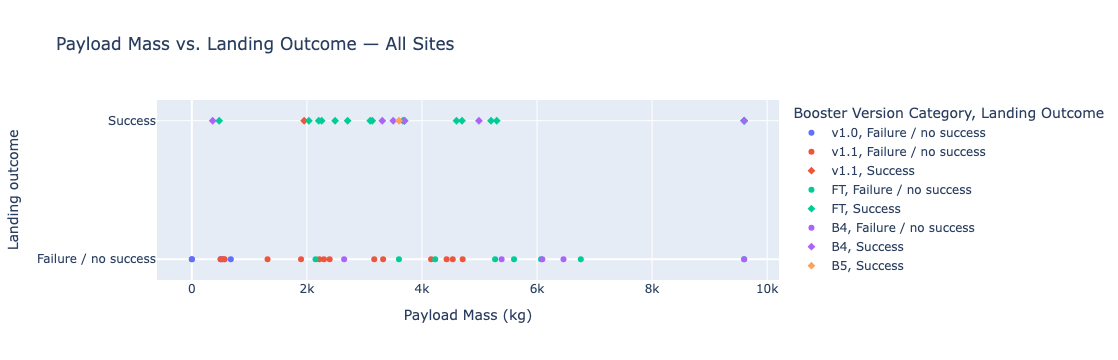

In [8]:
all_sites_scatter

## 8. Dashboard layout

The interaction design:

- a launch-site **dropdown** with `ALL` as the default;
- a payload **range slider**;
- a success/outcome **pie chart**;
- a payload-versus-outcome **scatter plot**.

In [19]:
def build_dash_app(dataframe):
    if not DASH_AVAILABLE:
        raise ImportError(
            "Dash is not installed in this environment. "
            "Install dash to run the interactive application."
        )

    app = Dash(__name__)
    app.title = "SpaceX Launch Analytics"

    slider_marks = {
        value: f"{value:,}"
        for value in range(0, 10001, 2000)
    }

    app.layout = html.Div(
        [
            html.H1(
                "SpaceX Falcon 9 Launch Analytics Dashboard",
                style={"textAlign": "center", "marginBottom": "6px"},
            ),
            html.P(
                "Explore historical first-stage landing outcomes by launch site "
                "and payload range.",
                style={"textAlign": "center", "marginTop": "0"},
            ),
            html.Div(
                [
                    html.Label("Launch site"),
                    dcc.Dropdown(
                        id="site-dropdown",
                        options=[
                            {"label": "All Sites", "value": "ALL"},
                            *[
                                {"label": site, "value": site}
                                for site in sorted(dataframe["Launch Site"].unique())
                            ],
                        ],
                        value="ALL",
                        clearable=False,
                        searchable=True,
                    ),
                ],
                style={"maxWidth": "760px", "margin": "20px auto"},
            ),
            dcc.Graph(id="success-pie-chart"),
            html.Div(
                [
                    html.Label("Payload range (kg)"),
                    dcc.RangeSlider(
                        id="payload-slider",
                        min=0,
                        max=10000,
                        step=500,
                        marks=slider_marks,
                        value=[min_payload, max_payload],
                        allowCross=False,
                        tooltip={"placement": "bottom", "always_visible": False},
                    ),
                ],
                style={"maxWidth": "900px", "margin": "20px auto 35px auto"},
            ),
            dcc.Graph(id="success-payload-scatter-chart"),
        ],
        style={
            "maxWidth": "1200px",
            "margin": "0 auto",
            "padding": "20px",
            "fontFamily": "Arial, sans-serif",
        },
    )

    @app.callback(
        Output("success-pie-chart", "figure"),
        Input("site-dropdown", "value"),
    )
    def update_pie(selected_site):
        return make_success_pie(selected_site)

    @app.callback(
        Output("success-payload-scatter-chart", "figure"),
        Input("site-dropdown", "value"),
        Input("payload-slider", "value"),
    )
    def update_scatter(selected_site, payload_range):
        return make_payload_scatter(selected_site, payload_range)

    return app


if DASH_AVAILABLE:
    app = build_dash_app(spacex_df)
    print("Dash application object created successfully.")
    print("Run the exported Python script to launch the interactive dashboard.")
else:
    app = None
    print("Dash is unavailable; analytical figure functions were still validated.")

Dash application object created successfully.
Run the exported Python script to launch the interactive dashboard.


Or run the dash app inside the notebook:

In [20]:
if __name__ == '__main__': 
    app.run(debug=True)

## Output Screenshots:

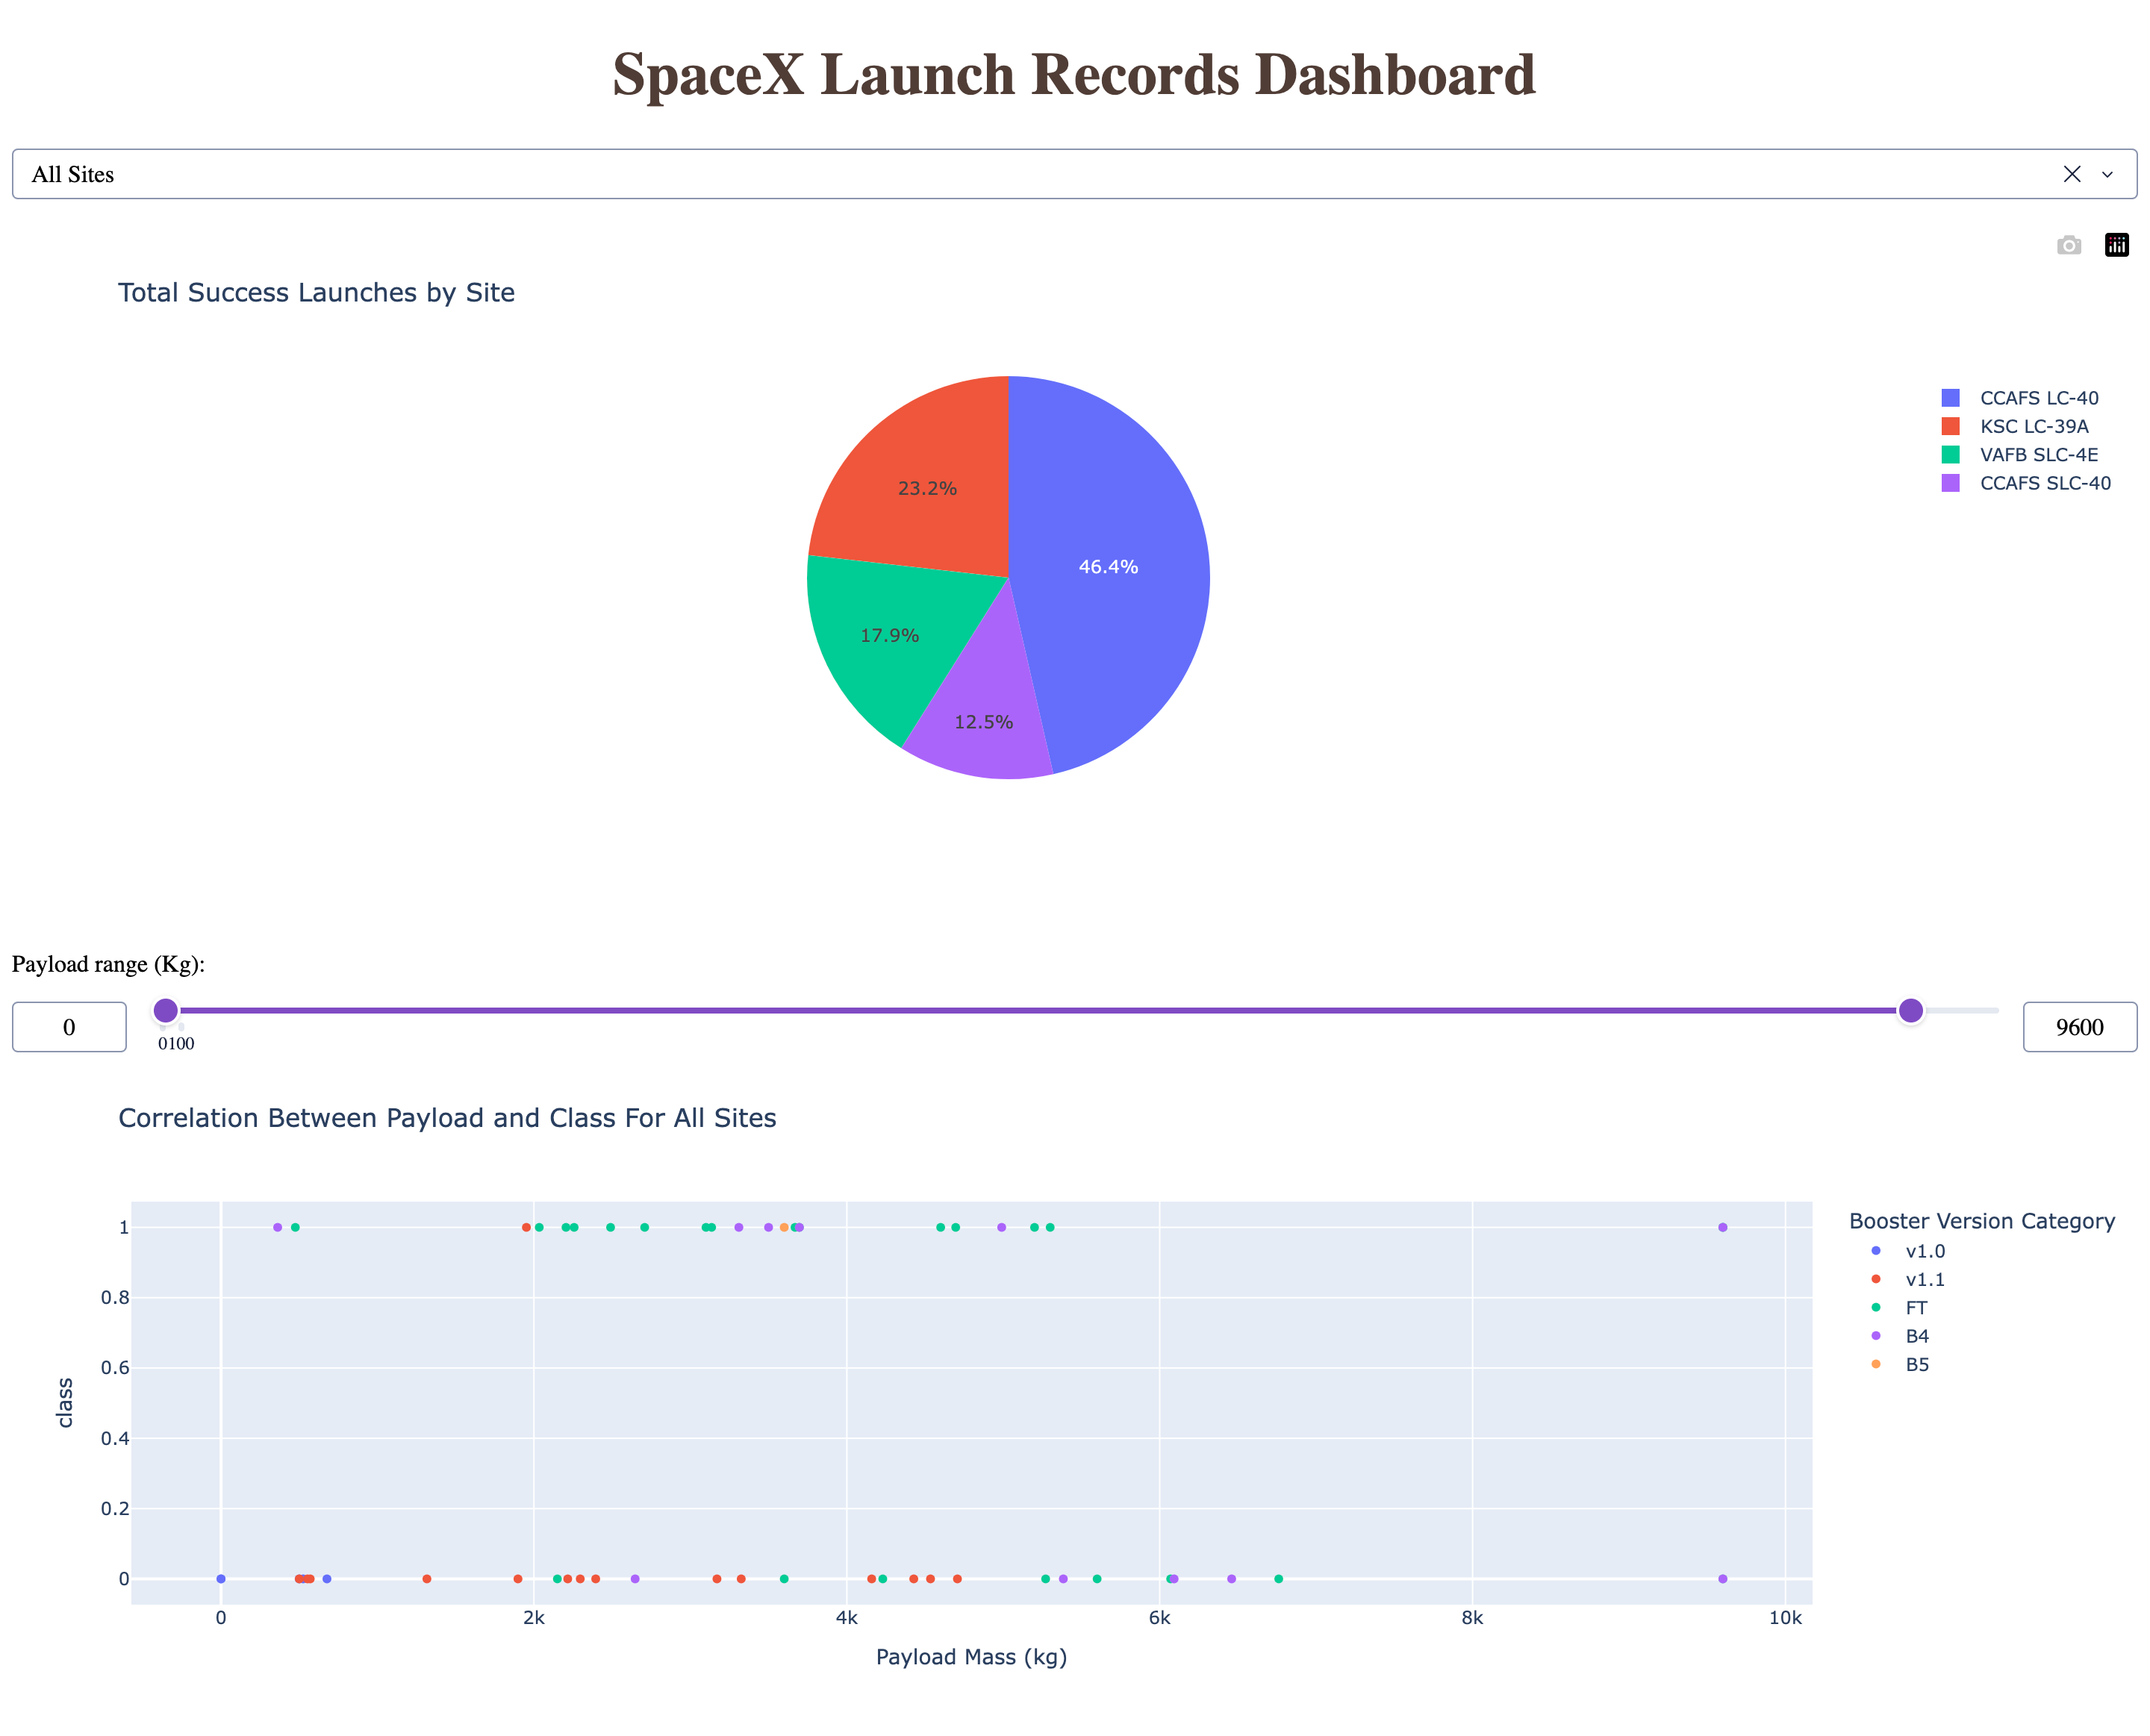

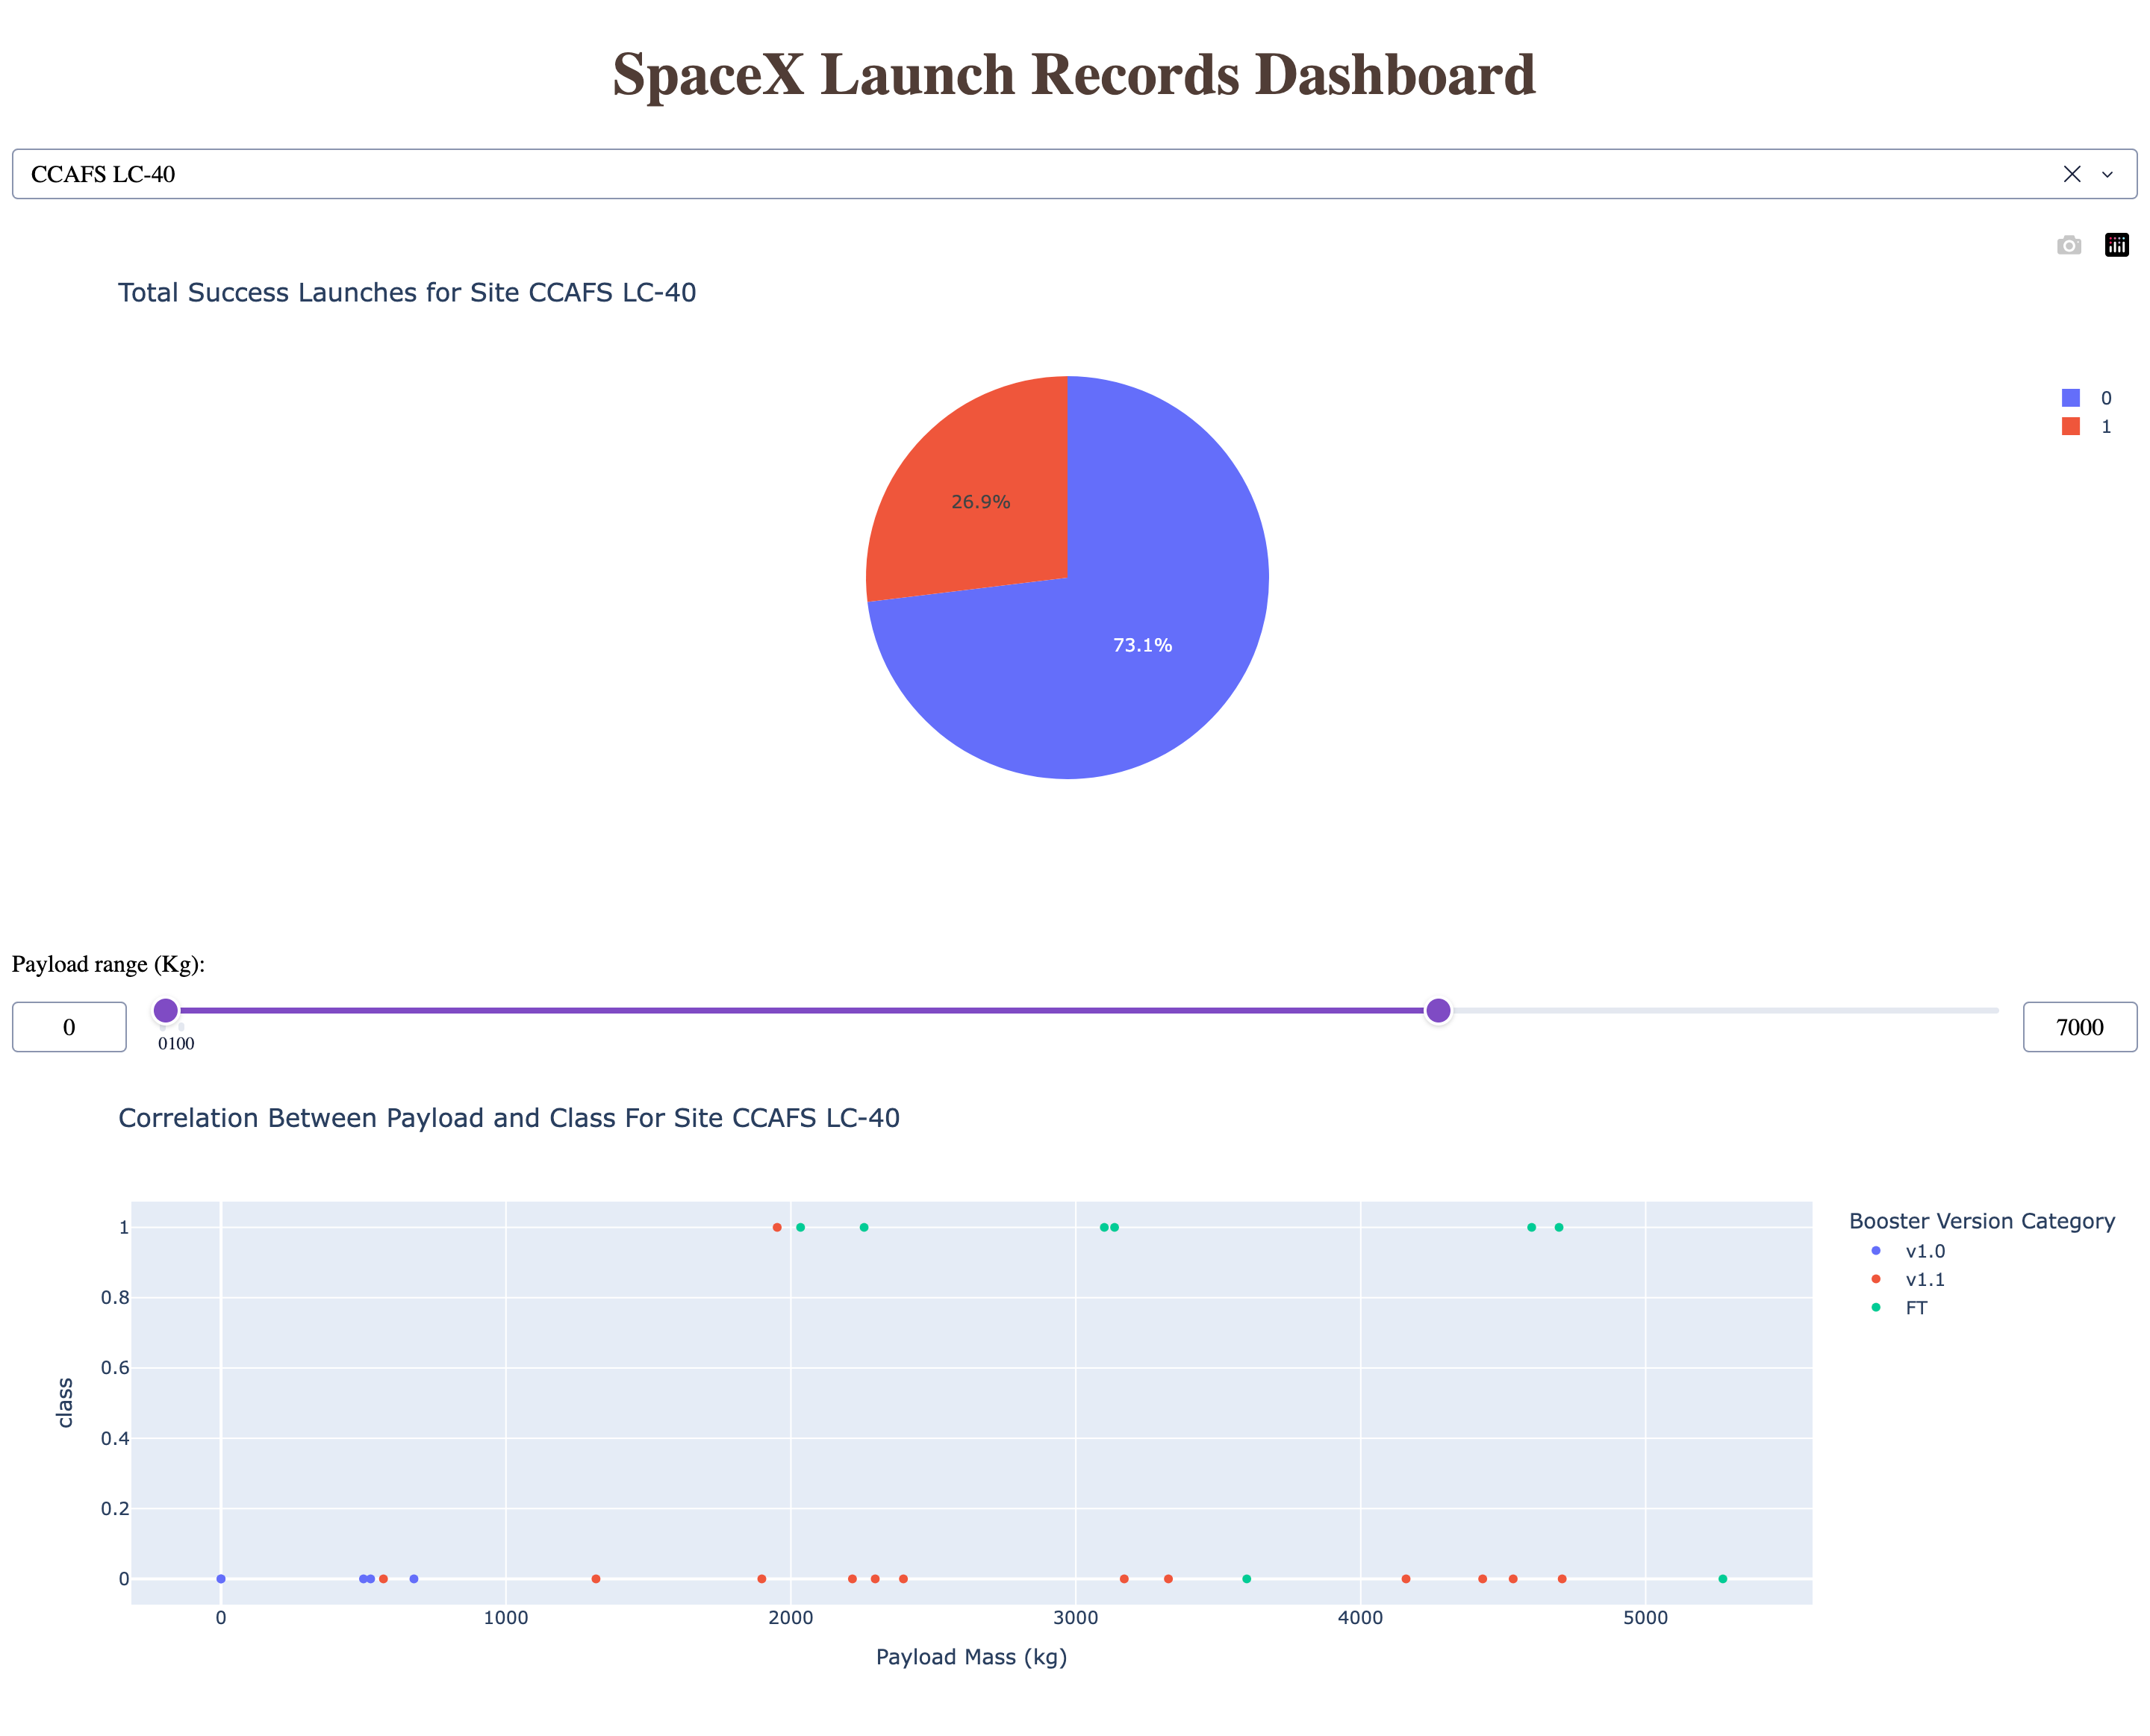

## 9. Export the standalone Dash application

A dashboard is more useful as a runnable `.py` application than as a notebook-only object. The next cell writes a self-contained portfolio script that expects `spacex_launch_dash.csv` in the same directory.

In [10]:
app_script = r"""from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output

DATA_PATH = Path(__file__).with_name("spacex_launch_dash.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH.name} must be stored in the same directory as this script."
    )

spacex_df = pd.read_csv(DATA_PATH)
if "Unnamed: 0" in spacex_df.columns:
    spacex_df = spacex_df.drop(columns="Unnamed: 0")

min_payload = float(spacex_df["Payload Mass (kg)"].min())
max_payload = float(spacex_df["Payload Mass (kg)"].max())
SITE_OPTIONS = ["ALL"] + sorted(spacex_df["Launch Site"].unique().tolist())


def make_success_pie(selected_site):
    if selected_site == "ALL":
        success_by_site = (
            spacex_df.loc[spacex_df["class"].eq(1)]
            .groupby("Launch Site")
            .size()
            .rename("Successful Landings")
            .reset_index()
        )
        return px.pie(
            success_by_site,
            values="Successful Landings",
            names="Launch Site",
            title="Successful Falcon 9 Landings by Launch Site",
            hole=0.25,
        )

    site_df = spacex_df.loc[spacex_df["Launch Site"].eq(selected_site)].copy()
    outcome_counts = (
        site_df["class"]
        .map({0: "Failure / no success", 1: "Success"})
        .value_counts()
        .rename_axis("Outcome")
        .reset_index(name="Missions")
    )
    return px.pie(
        outcome_counts,
        values="Missions",
        names="Outcome",
        title=f"Landing Outcomes — {selected_site}",
        hole=0.25,
    )


def make_payload_scatter(selected_site, payload_range):
    low, high = map(float, payload_range)
    filtered = spacex_df.loc[
        spacex_df["Payload Mass (kg)"].between(low, high, inclusive="both")
    ].copy()

    if selected_site != "ALL":
        filtered = filtered.loc[filtered["Launch Site"].eq(selected_site)]

    scope = "All Sites" if selected_site == "ALL" else selected_site

    if filtered.empty:
        fig = go.Figure()
        fig.add_annotation(
            text="No missions match the selected site and payload range.",
            x=0.5, y=0.5, xref="paper", yref="paper",
            showarrow=False,
        )
        fig.update_layout(
            title=f"Payload Mass vs. Landing Outcome — {scope}",
            xaxis_title="Payload Mass (kg)",
            yaxis_title="Landing outcome",
        )
        return fig

    filtered["Landing Outcome"] = filtered["class"].map(
        {0: "Failure / no success", 1: "Success"}
    )
    fig = px.scatter(
        filtered,
        x="Payload Mass (kg)",
        y="class",
        color="Booster Version Category",
        symbol="Landing Outcome",
        hover_data=[
            "Flight Number", "Launch Site",
            "Booster Version", "Landing Outcome"
        ],
        title=f"Payload Mass vs. Landing Outcome — {scope}",
    )
    fig.update_yaxes(
        tickmode="array",
        tickvals=[0, 1],
        ticktext=["Failure / no success", "Success"],
        range=[-0.15, 1.15],
        title="Landing outcome",
    )
    return fig


app = Dash(__name__)
app.title = "SpaceX Launch Analytics"

app.layout = html.Div(
    [
        html.H1(
            "SpaceX Falcon 9 Launch Analytics Dashboard",
            style={"textAlign": "center", "marginBottom": "6px"},
        ),
        html.P(
            "Explore historical first-stage landing outcomes by launch site "
            "and payload range.",
            style={"textAlign": "center", "marginTop": "0"},
        ),
        html.Div(
            [
                html.Label("Launch site"),
                dcc.Dropdown(
                    id="site-dropdown",
                    options=[
                        {"label": "All Sites", "value": "ALL"},
                        *[
                            {"label": site, "value": site}
                            for site in sorted(spacex_df["Launch Site"].unique())
                        ],
                    ],
                    value="ALL",
                    clearable=False,
                    searchable=True,
                ),
            ],
            style={"maxWidth": "760px", "margin": "20px auto"},
        ),
        dcc.Graph(id="success-pie-chart"),
        html.Div(
            [
                html.Label("Payload range (kg)"),
                dcc.RangeSlider(
                    id="payload-slider",
                    min=0,
                    max=10000,
                    step=500,
                    marks={v: f"{v:,}" for v in range(0, 10001, 2000)},
                    value=[min_payload, max_payload],
                    allowCross=False,
                    tooltip={"placement": "bottom", "always_visible": False},
                ),
            ],
            style={"maxWidth": "900px", "margin": "20px auto 35px auto"},
        ),
        dcc.Graph(id="success-payload-scatter-chart"),
    ],
    style={
        "maxWidth": "1200px",
        "margin": "0 auto",
        "padding": "20px",
        "fontFamily": "Arial, sans-serif",
    },
)


@app.callback(
    Output("success-pie-chart", "figure"),
    Input("site-dropdown", "value"),
)
def update_pie(selected_site):
    return make_success_pie(selected_site)


@app.callback(
    Output("success-payload-scatter-chart", "figure"),
    Input("site-dropdown", "value"),
    Input("payload-slider", "value"),
)
def update_scatter(selected_site, payload_range):
    return make_payload_scatter(selected_site, payload_range)


if __name__ == "__main__":
    app.run(debug=False)
"""

APP_OUTPUT_PATH.write_text(app_script, encoding="utf-8")
print(f"Saved standalone dashboard application to: {APP_OUTPUT_PATH.resolve()}")

Saved standalone dashboard application to: /Users/mac/Downloads/spacex_dash_app_portfolio.py


## 10. Dashboard findings

The dashboard dataset supports the following answers to the visual-analysis questions:

1. **Largest successful-landing count:** KSC LC-39A, with **10 successful landings**.
2. **Highest observed site success rate:** KSC LC-39A, **76.9% (10/13)**.
3. **Highest fixed 2,000 kg payload-band success rate:** **2,000–4,000 kg, 61.9% (13/21)** in the reproducible audit bands used here. The 8,000–10,000 kg group is close at 60.0% but contains only five missions.
4. **Lowest fixed payload-band success rate:** **6,000–8,000 kg, 0% (0/4)**.
5. **Highest nominal booster-category rate:** `B5` at 100%, but this is based on only **one mission**. Among booster categories with multiple observations, `FT` is highest at **66.7% (16/24)**.

### Important interpretation

The dashboard is an exploratory interface, not a causal model. Site, payload, booster generation, and mission timing are interrelated. In particular, the strong performance of later booster categories and KSC missions may partly reflect the maturation of the Falcon 9 recovery program over time.

The payload-range conclusions also depend on how ranges are defined. The dashboard's continuous slider allows users to inspect arbitrary intervals; the fixed 2,000 kg bands above are included only to make the portfolio findings reproducible and auditable.

### Analytical handoff

**Notebook 08** uses the modeling dataset and engineered features from the earlier analytical pipeline to evaluate landing-success classifiers. Unlike this dashboard, which is designed for interactive exploration, Notebook 08 focuses on predictive performance and model generalization.

## Project attribution

This portfolio notebook builds on the Plotly Dash stage of the **IBM Data Science Professional Certificate SpaceX capstone**. The original `spacex_launch_dash.csv` dataset, dropdown/slider interaction, pie-chart task, and payload scatter task are retained. The implementation has been refactored for analytical workflow, testability, clearer interpretation, and portfolio presentation.